In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv("cleaned_stock_prices.csv")
df["date"] = pd.to_datetime(df["date"])

# keep only stocks with a full trading history, so all comparisons are apples-to-apples
counts = df.groupby("symbol").size()
full_symbols = counts[counts == counts.max()].index
df = df[df["symbol"].isin(full_symbols)].copy()
print("Stocks with full history:", df["symbol"].nunique())

df = df.sort_values(["symbol", "date"])
df["daily_return"] = df.groupby("symbol")["close"].pct_change()

# one row per stock, summarizing its behavior over the full period
features = df.groupby("symbol").agg(
    avg_daily_return=("daily_return", "mean"),
    volatility=("daily_return", "std"),
    avg_volume=("volume", "mean"),
    avg_close=("close", "mean")
).dropna()

print(features.shape)
features.describe()

Stocks with full history: 477
(477, 4)


,avg_daily_return,volatility,avg_volume,avg_close
count,477.000000,477.000000,4.770000e+02,477.000000
mean,0.000462,0.015453,4.285186e+06,85.507037
std,0.000433,0.004864,6.830088e+06,93.829867
min,-0.001135,0.008284,1.719199e+05,5.908605
25%,0.000200,0.012165,1.325574e+06,43.954141
50%,0.000477,0.014335,2.289204e+06,67.900338
75%,0.000707,0.017413,4.316553e+06,99.433083
max,0.002760,0.045515,8.936290e+07,1390.272642


In [2]:
X = features[["avg_daily_return", "volatility", "avg_volume", "avg_close"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

C:\Users\FBDA22-007\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\FBDA22-007\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\FBDA22-007\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\FBDA22-007\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

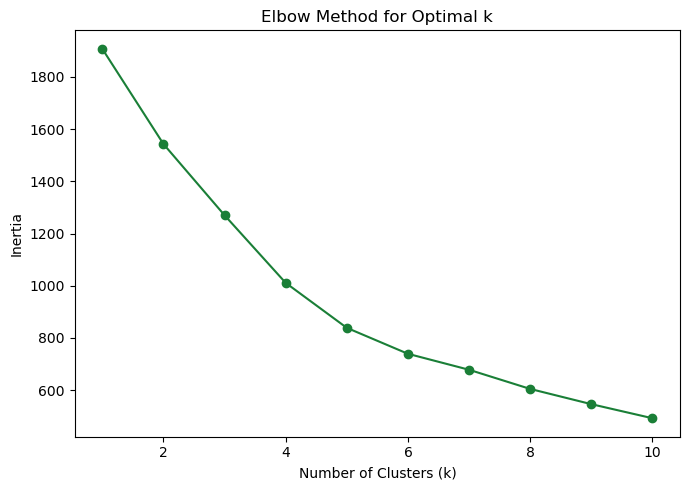

In [3]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertias, marker="o", color="#1a7f37")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.savefig("elbow.png", dpi=150)
plt.show()

In [4]:
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
features["cluster"] = kmeans.fit_predict(X_scaled)

features.groupby("cluster")[["avg_daily_return", "volatility", "avg_volume", "avg_close"]].mean()

C:\Users\FBDA22-007\conda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,avg_daily_return,volatility,avg_volume,avg_close
cluster,,,,
0,0.000523,0.016307,1.568695e+06,781.834445
1,0.000566,0.013742,3.027099e+06,83.085814
2,0.000030,0.021909,4.838781e+06,64.355862
3,0.000622,0.016280,3.424862e+07,41.785505


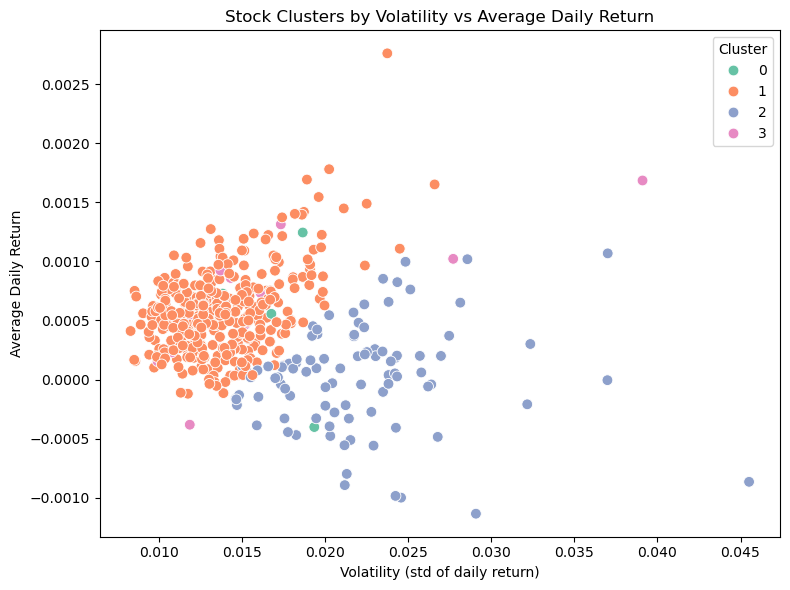

In [5]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=features, x="volatility", y="avg_daily_return",
    hue="cluster", palette="Set2", s=60
)
plt.title("Stock Clusters by Volatility vs Average Daily Return")
plt.xlabel("Volatility (std of daily return)")
plt.ylabel("Average Daily Return")
plt.legend(title="Cluster")
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150)
plt.show()